In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)

In [111]:
args <- list(
    spa_file = "data/conditional/common/spa_iter/new_run_friday/ukb_eur_wes_200k_maf0to5e-2_PSOR_combined_pLoF_damaging_missense_cond_i1.mrg",
    col_pvalue_cond = "p.value_c",
    col_pvalue = "p.value",
    p_cutoff = 5e-6
)

In [112]:
  stopifnot(file.exists(args$spa_file))

In [113]:
z_to_log10p <- function(z) {
      abs((pnorm(-abs(z),log.p=TRUE)+log(2))/log(10))
}

t_to_log10p <- function(t) {
      abs(pt(t, length(t) - 1,  log.p = TRUE)+log(2))/log(10)
}




In [117]:
# read and check integratity of file
d <- fread(args$spa_file, header = TRUE)
cols <- colnames(d)
stopifnot(nrow(d) > 0)

# always use conditional P-valu column if present
if (args$col_pvalue_cond %in% cols) {
    col_pvalue <- args$col_pvalue_cond
    col_tstat <- "Tstat_c"
    col_beta <- "BETA_c"
    col_se <- "SE_c"
} else if (args$col_pvalue %in% cols) {
    col_pvalue <- args$col_pvalue
    col_tstat <- "Tstat"
    col_beta <- "BETA"
    col_se <- "SE"
} else {
    stop(paste(args$col_pvalue,"/",args$col_pvalue_cond, "not in",args$spa_file))
}

# only keep the follow columns in the output file
keep_cols <- c("CHR", "POS", "MarkerID", "Allele1", "Allele2",
             "AC_allele2", "AF_Allele2", "BETA", "SE", "Tstat",
             "var", "p.value", "Tstat_c", "p.value_c", "varT_c",
             "BETA_c", "SE_c")

# subset columns
d <- d[,colnames(d) %in% keep_cols, with = FALSE]
d_marker <- d[ ,c("CHR", "POS", "Allele1", "Allele2") ]

# create new data.table containing currently used columns
marker <- apply(d_marker, 1, paste, collapse = ":" )
dt <- data.table(cur_marker = marker)
dt$cur_pvalue <- d[[col_pvalue]]
dt$cur_tstat <- d[[col_tstat]]
dt$cur_tstat_pvalue <- 2 * pt(dt$cur_tstat, nrow(dt) - 1, lower.tail = TRUE)
dt$cur_tstat_log10_pvalue <- t_to_log10p(dt$cur_tstat)
dt$cur_zstat <- d[[col_beta]] / d[[col_se]]
dt$cur_zstat_pvalue <- 2 * pnorm(abs(dt$cur_zstat), lower.tail = FALSE)
dt$cur_zstat_log10_pvalue <- z_to_log10p(dt$cur_zstat)

# do some checks
marker_zstat_p <- dt$cur_marker[which(dt$cur_zstat_log10_pvalue == max(dt$cur_zstat_log10_pvalue))]
marker_cur_p <- dt$cur_marker[which(dt$cur_pvalue == min(dt$cur_pvalue))]

if (marker_zstat_p != marker_cur_p){
    write("Discrepancy found:", stdout())
    d_subset <- dt[dt$cur_marker %in% c(marker_zstat_p, marker_cur_p)]
    print(d_subset)
}

# combine with original
d <- data.table(cbind(dt, d))
p_cutoff <- as.numeric(args$p_cutoff)
bool_keep <- d$cur_pvalue < p_cutoff
#d <- d[bool_keep, ]

# ensure that most significant marker is at bottom
#d <- d[rev(order(d$cur_zstat_pvalue)),]
d <- d[order(abs(d$cur_tstat)),]
tail(d)

Warning message in fread(args$spa_file, header = TRUE):
"Discarded single-line footer: <<chr6	32719070	rs28772318	>>"


cur_marker,cur_pvalue,cur_tstat,cur_tstat_pvalue,cur_tstat_log10_pvalue,cur_zstat,cur_zstat_pvalue,cur_zstat_log10_pvalue,CHR,POS,MarkerID,Allele1,Allele2,AF_Allele2,BETA,SE,Tstat,var,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr6:31351829:G:A,1.44165e-197,928.833,2,0.30103,29.98714,1.443713e-197,196.8405,chr6,31351829,rs28732140,G,A,0.130313,1.264150,0.0421564,928.833,734.749,1.44165e-197
chr6:31335554:C:T,2.68177e-198,929.154,2,0.30103,30.04307,2.689418e-198,197.5703,chr6,31335554,rs28732122,C,T,0.130282,1.268160,0.0422114,929.154,732.677,2.68177e-198
chr6:31332105:A:G,1.32604e-199,929.392,2,0.30103,30.14290,1.328784e-199,198.8765,chr6,31332105,rs13191852,A,G,0.129492,1.277610,0.0423851,929.392,727.444,1.32604e-199
chr6:31346230:AC:A,1.66763e-157,929.484,2,0.30103,26.73876,1.668446e-157,156.7777,chr6,31346230,6:31314007_AC_A,AC,A,0.190811,0.934386,0.0349450,929.484,994.753,1.66763e-157
chr6:31308635:G:A,2.61834e-193,933.760,2,0.30103,29.65871,2.618787e-193,192.5819,chr6,31308635,rs17192631,G,A,0.136536,1.220100,0.0411380,933.760,765.314,2.61834e-193
chr6:31351254:G:T,2.67446e-199,937.378,2,0.30103,30.11977,2.669655e-199,198.5735,chr6,31351254,rs1811198,G,T,0.132185,1.262130,0.0419037,937.378,742.697,2.67446e-199


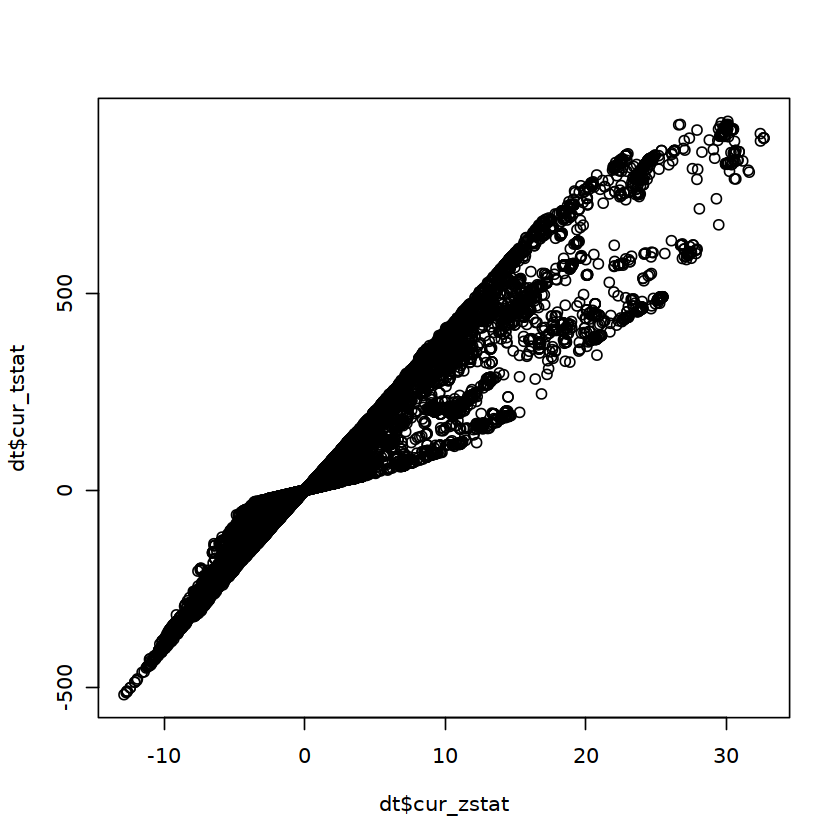

In [118]:
plot(dt$cur_zstat, dt$cur_tstat)

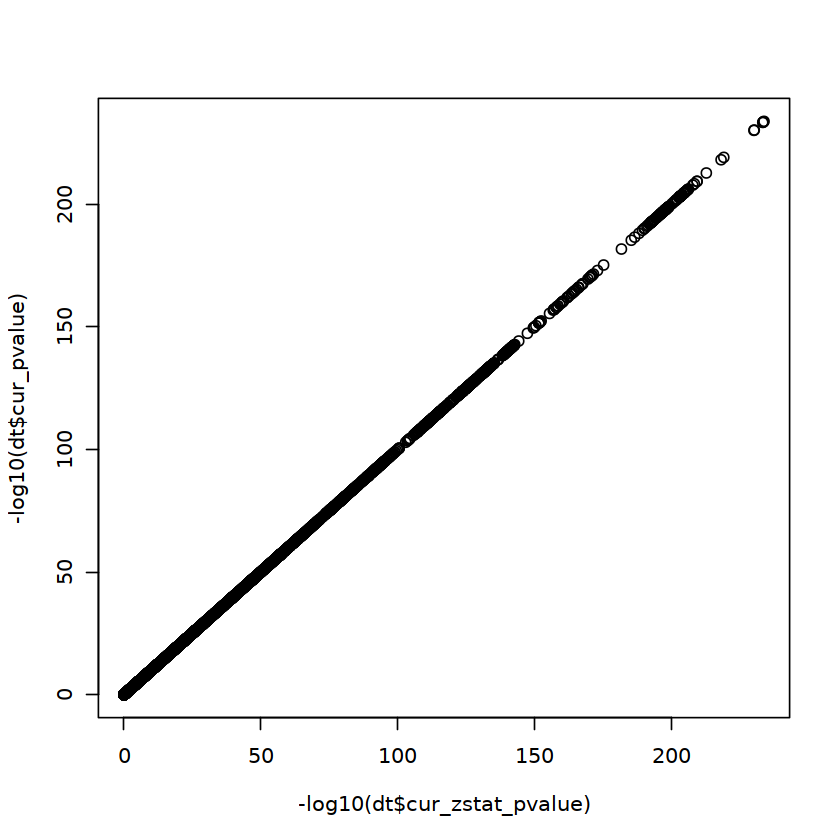

In [119]:
plot(-log10(dt$cur_zstat_pvalue), -log10(dt$cur_pvalue))

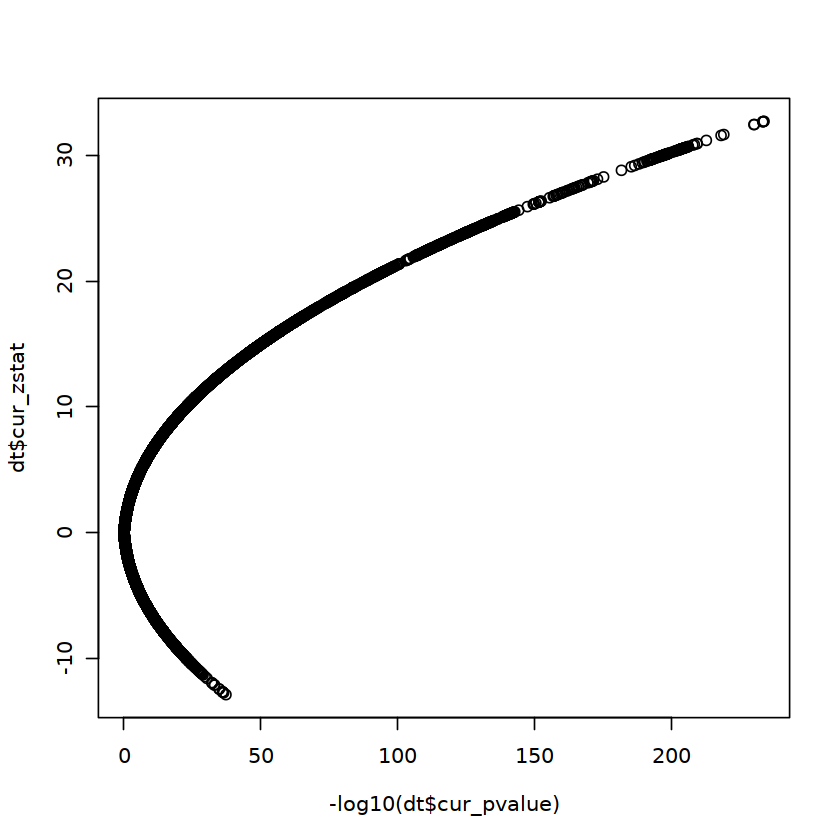

In [120]:
#data/conditional/common/spa_iter/new_run_friday/ukb_eur_wes_200k_maf0to5e-2_AD_combined_pLoF_damaging_missense_cond_i1.mrg
plot(-log10(dt$cur_pvalue), dt$cur_zstat)

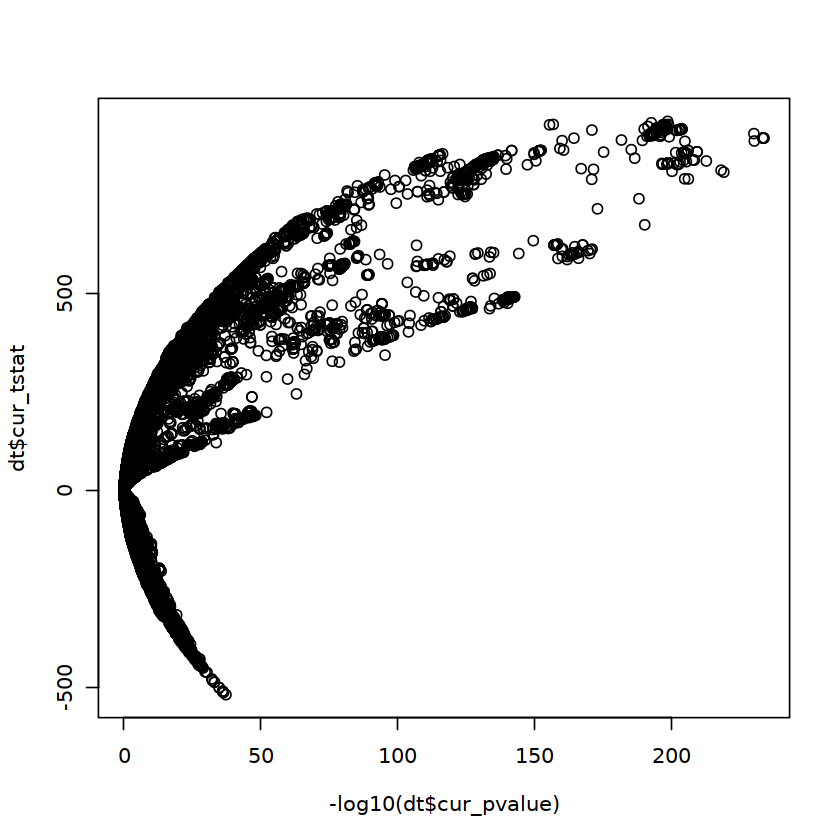

In [121]:
plot(-log10(dt$cur_pvalue), dt$cur_tstat)

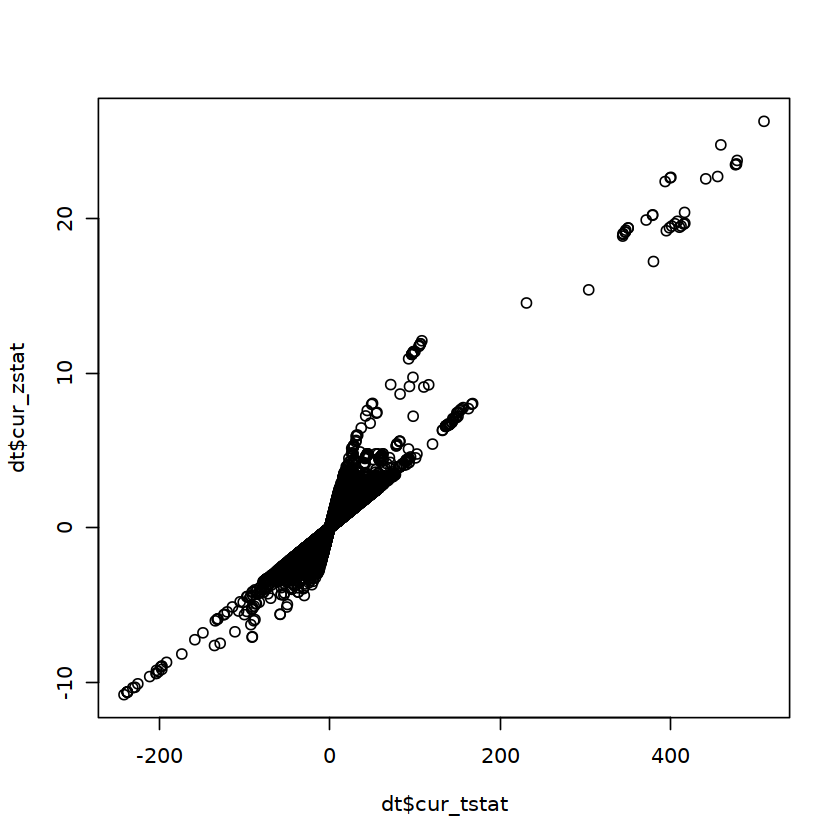

In [70]:
plot(dt$cur_tstat, dt$cur_zstat)

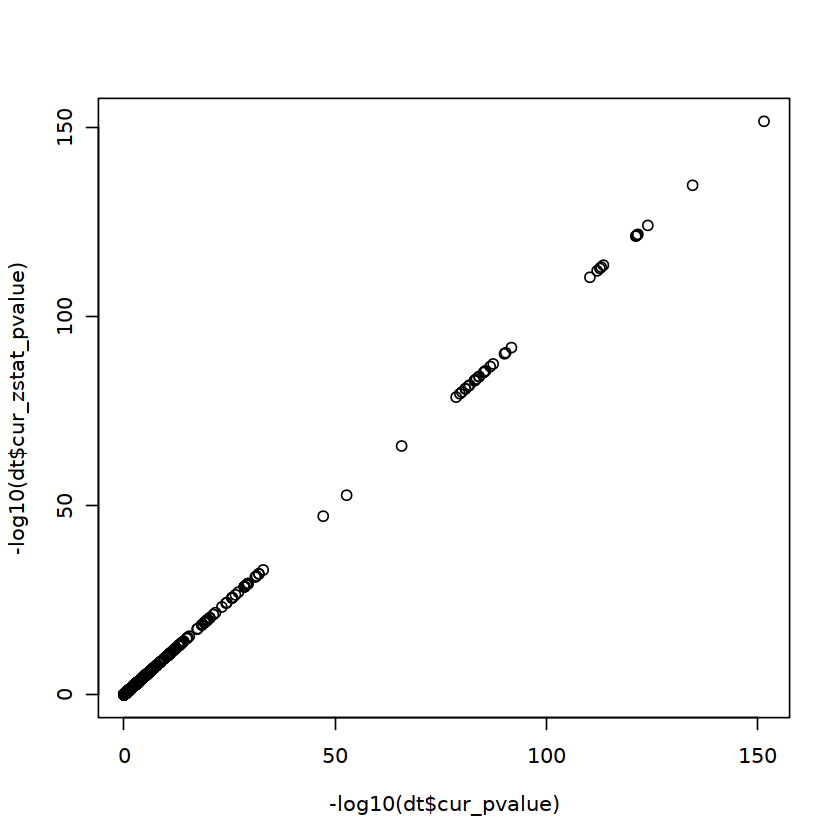

In [80]:
plot(-log10(dt$cur_pvalue), -log10(dt$cur_zstat_pvalue))

In [24]:
p_cutoff <- as.numeric(args$p_cutoff)
bool <- d$cur_pvalue < p_cutoff

In [27]:
pvalue

[1]  6.49173e-01  3.62455e-01  7.54294e-01  1.40419e-01  7.68925e-01
    [6]  3.34807e-01  2.62804e-01  7.76163e-01  2.61530e-01  8.25541e-01
   [11]  2.91875e-01  2.50894e-01  1.14253e-01  6.74097e-01  9.30875e-01
   [16]  2.47066e-01  3.84755e-01  7.32704e-01  7.64483e-01  7.07454e-01
   [21]  1.93281e-01  8.04526e-01  6.59158e-01  4.81709e-01  2.82766e-01
   [26]  1.77620e-01  8.69836e-01  4.54479e-01  6.91514e-01  9.96684e-01
   [31]  1.44459e-01  1.51461e-01  6.19146e-02  6.37088e-02  2.21664e-01
   [36]  2.91213e-01  1.42076e-01  6.70250e-01  1.44631e-01  2.49373e-01
   [41]  4.25376e-01  5.99275e-01  9.90491e-02  3.11536e-01  1.21408e-01
   [46]  1.52550e-01  4.47720e-01  5.01300e-01  4.81423e-01  5.50774e-01
   [51]  4.55302e-01  6.38776e-01  5.08296e-01  6.45028e-01  5.97460e-01
   [56]  5.24603e-01  6.19638e-01  7.33238e-01  1.55949e-01  7.50085e-01
   [61]  4.64863e-01  7.77357e-01  2.20674e-01  4.55915e-01  3.03114e-01
   [66]  5.69828e-01  3.01112e-01  4.49669e-01  4.75172e-01  4.74405e-01
   [71]  3.75986e-01  4.00967e-01  4.34913e-01  4.93801e-01  1.65897e-01
   [76]  9.38116e-01  5.40000e-01  3.08536e-01  4.55248e-01  2.53383e-01
   [81]  5.21234e-01  2.53068e-01  7.50038e-01  2.67903e-01  7.39988e-02
   [86]  9.66481e-01  5.26610e-01  5.40369e-01  2.74636e-01  4.13460e-01
   [91]  4.07742e-01  5.53285e-01  2.68375e-01  3.93395e-01  2.69415e-01
   [96]  3.91584e-01  3.91584e-01  2.89152e-01  3.39160e-01  3.98255e-01
  [101]  3.81691e-01  3.89868e-01  3.93343e-01  3.84064e-01  3.83667e-01
  [106]  3.83667e-01  3.83714e-01  3.83013e-01  1.05830e-01  6.79629e-01
  [111]  3.90500e-01  4.19635e-01  3.58836e-01  4.11235e-01  3.32168e-01
  [116]  3.40438e-01  3.25576e-01  3.38213e-01  3.10858e-01  2.08197e-01
  [121]  3.25023e-01  1.77012e-01  1.59266e-01  2.76414e-01  3.91972e-01
  [126]  9.59199e-01  8.69045e-01  4.63604e-01  1.83435e-01  3.80202e-01
  [131]  1.91326e-01  7.69530e-01  5.51223e-01  9.88061e-01  9.48280e-01
  [136]  6.06328e-01  9.46721e-01  8.50852e-01  9.76937e-01  7.11991e-01
  [141]  6.52031e-01  4.04232e-01  9.56846e-01  6.06604e-02  9.56858e-01
  [146]  4.10457e-01  4.86288e-01  6.19368e-01  9.37636e-01  6.69056e-01
  [151]  6.05045e-01  8.91203e-01  2.68211e-01  3.75666e-01  1.73685e-01
  [156]  8.61193e-01  6.42132e-01  4.05268e-01  6.54999e-01  6.30293e-01
  [161]  6.88172e-01  7.56232e-01  2.64480e-01  7.02476e-01  6.48738e-01
  [166]  5.88246e-01  6.05128e-02  8.77445e-01  3.58275e-02  8.46058e-01
  [171]  6.43371e-01  8.81292e-01  3.87854e-01  5.59585e-02  7.62214e-01
  [176]  8.34655e-01  5.32815e-01  4.61254e-01  9.23193e-01  4.55125e-01
  [181]  9.37687e-01  4.89007e-01  3.62371e-01  8.96035e-01  5.89486e-01
  [186]  3.96004e-02  6.51192e-01  9.13243e-01  6.48572e-01  7.48916e-01
  [191]  9.36329e-01  2.49938e-01  1.98560e-01  2.03979e-01  3.37328e-02
  [196]  4.60909e-02  4.04485e-01  7.01510e-02  9.06806e-02  7.54850e-02
  [201]  9.51727e-01  4.20958e-01  3.65952e-01  5.36327e-01  8.11431e-01
  [206]  2.72254e-01  3.93584e-01  6.36809e-01  4.80516e-01  4.34196e-01
  [211]  3.34916e-01  3.70138e-01  5.49973e-01  4.57230e-01  3.60467e-01
  [216]  8.61105e-01  8.61105e-01  3.45898e-01  3.85699e-01  2.94935e-01
  [221]  2.74731e-01  2.95973e-01  2.73319e-01  2.72890e-01  5.22265e-01
  [226]  1.78333e-01  5.60917e-01  2.72317e-01  3.03214e-01  3.32701e-01
  [231]  3.32701e-01  3.18121e-01  9.41262e-01  5.64994e-01  4.53188e-01
  [236]  3.78625e-02  3.11883e-01  5.77042e-01  6.58659e-01  2.82217e-01
  [241]  3.07466e-01  2.99480e-01  2.75927e-01  4.24459e-01  3.78392e-02
  [246]  6.88701e-01  7.60289e-01  2.76251e-01  3.62989e-01  2.76429e-01
  [251]  3.79185e-02  1.89099e-01  3.99704e-01  7.82817e-01  3.56454e-01
  [256]  7.56200e-01  2.76789e-01  7.57333e-01  7.92913e-01  6.09075e-01
  [261]  4.01968e-02  3.79648e-01  9.52902e-02  9.88240e-02  6.80268e-01
  [266]  4.56240e-01  3.49547e-02  3.31317e-01  3.77193e-01  3.36235e-01
  [271]  4.99842e-03  5.49968e-02  4.21072e-03  6.02775e-01  4

In [6]:
f1 <- "data/conditional/common/spa_iter/new_run_tuesday/ukb_eur_wes_200k_maf0to5e-2_AD_combined_pLoF_damaging_missense_cond_i2.mrg"
f2 <- "data/conditional/common/spa_iter/new_run_thursday/ukb_eur_wes_200k_maf0to5e-2_AD_combined_pLoF_damaging_missense_cond_i2.mrg"
f3 <- "data/conditional/common/spa_iter/new_run_saturday_saigev1_1_1/ukb_eur_wes_200k_maf0to5e-2_AD_combined_pLoF_damaging_missense_cond_i2.mrg"

In [7]:
d1 <- fread(f1)
d2 <- fread(f2)
d3 <- fread(f3)

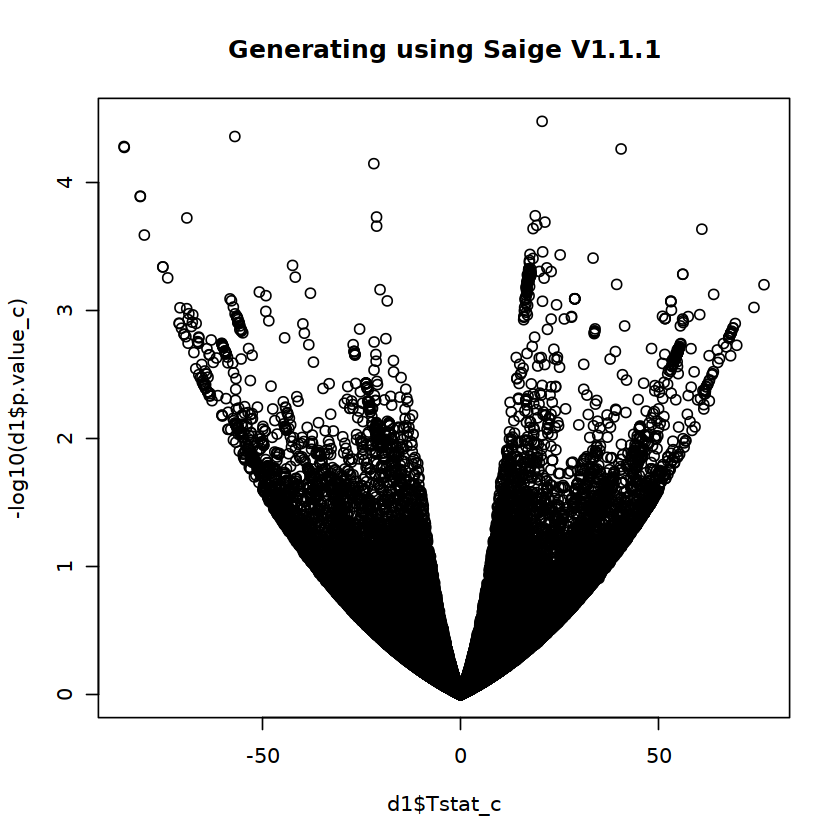

In [9]:
plot(d1$Tstat_c, -log10(d1$p.value_c), main = "Generating using Saige V1.1.1")

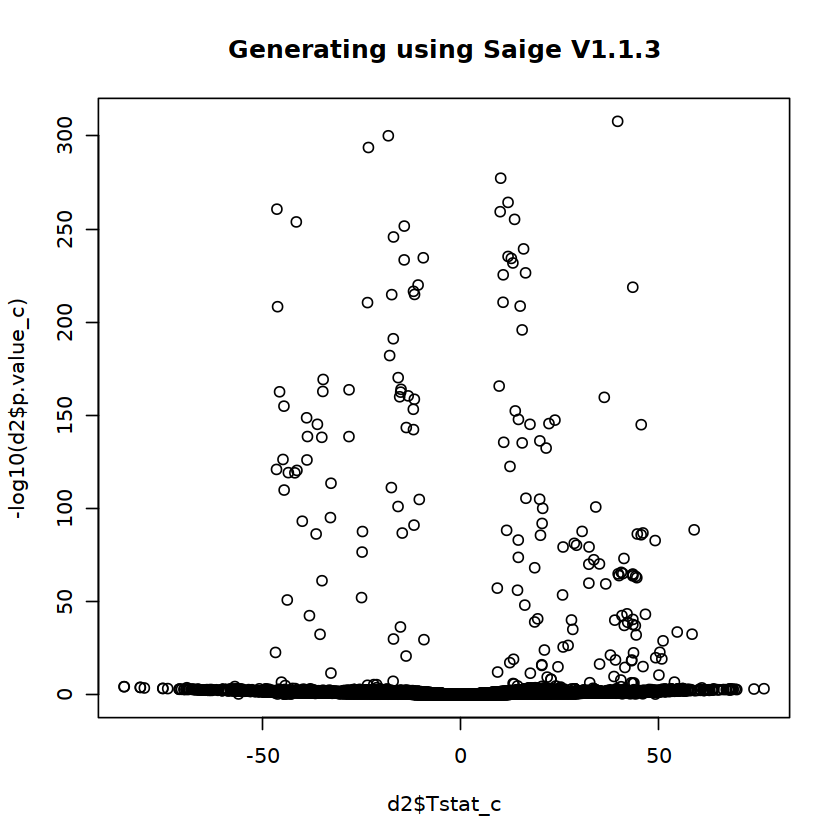

In [10]:
plot(d2$Tstat_c, -log10(d2$p.value_c), main = "Generating using Saige V1.1.3")

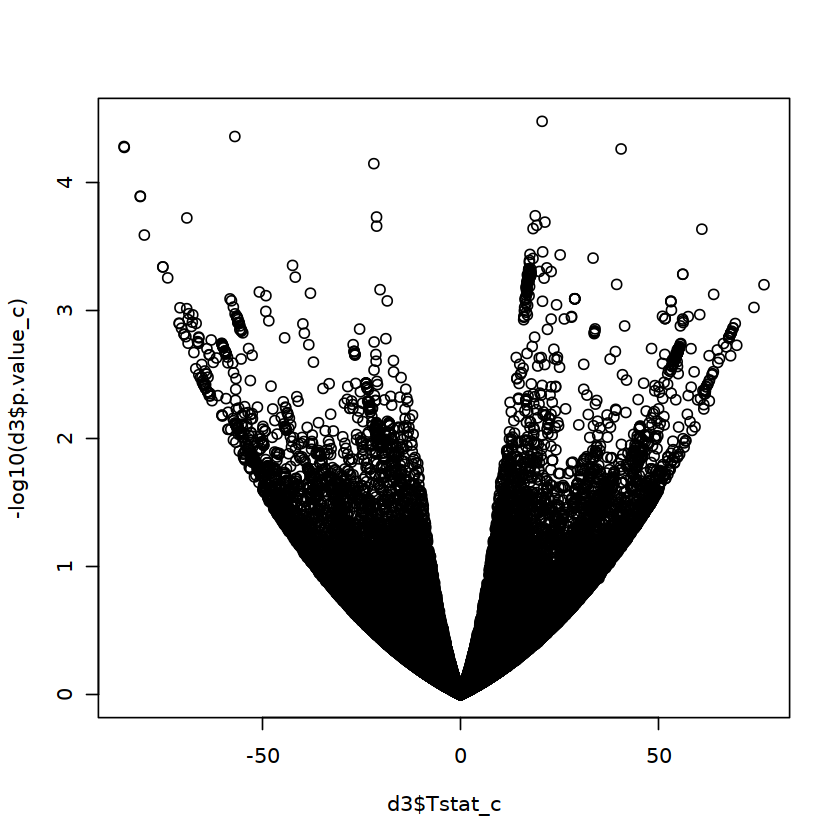

In [8]:
plot(d3$Tstat_c, -log10(d3$p.value_c))

In [192]:
trow <- rowSums(d1 != d2) > 0
tcol <- colSums(d1 != d2) > 0
d2[trow,tcol,with=FALSE]

SE_c,p.value_c
<dbl>,<dbl>
0.06113250,7.16576e-13
0.30193300,4.04192e-01
0.00000000,0.00000e+00
0.05123210,8.48052e-05
0.00701739,2.88376e-146
0.01346880,2.53088e-159
0.00770562,3.96486e-148
0.05802240,1.64335e-03
0.06651320,1.67711e-01


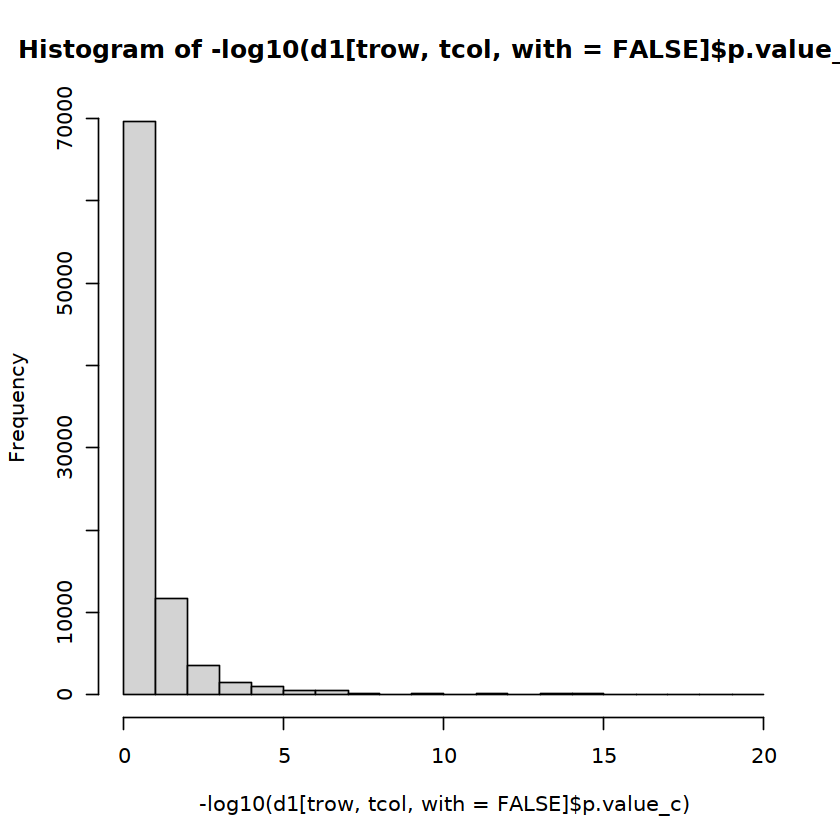

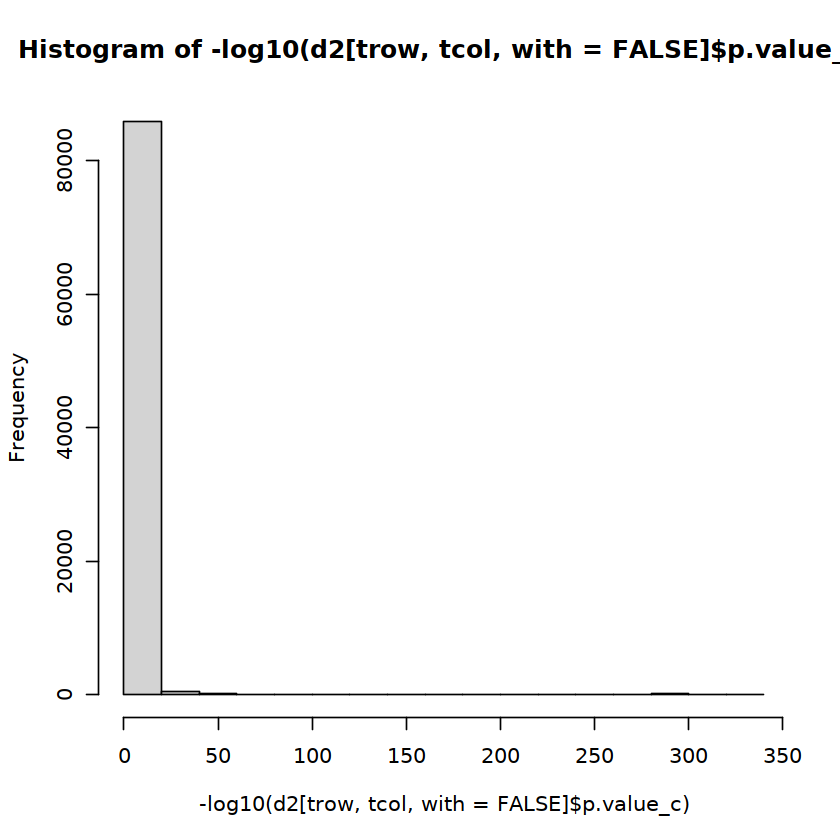

In [166]:
hist(-log10(d1[trow,tcol,with=FALSE]$p.value_c)); 
hist(-log10(d2[trow,tcol,with=FALSE]$p.value_c))

In [89]:
args <- list(
    out_prefix="data/conditional/rare/combined/ukb_eur_wes_200k_chr21_maf0to5e-2_pLoF_damaging_missense_ld"

)

In [94]:
files <- list.files(dirname(args$out_prefix), pattern = basename(args$out_prefix), full.names = TRUE)
files_hash <- files[grepl("hash.txt.gz",files)][1:5]
files_ac <- files[grepl("AC.txt.gz",files)][1:5]

# get columns with IDs
col_id <- c("chr","pos","id","ref","alt")

# get starting columns with markers
markers <- fread(files[[1]])[,col_id,with=FALSE]
marker_id <- markers$id

# get hashes
lst_hash <- lapply(files_hash, function(f){
    d <- fread(f)
    stopifnot(all(marker_id == d$id))
    d <- d[,-col_id,with=FALSE]
    return(d)
})

# get AC
lst_ac <- lapply(files_ac, function(f){
    d <- fread(f)
    stopifnot(all(marker_id == d$id))
    d <- d[,-col_id,with=FALSE]
    return(d)
})

# combine them all
d_hash <- cbind(markers, do.call(cbind, lst_hash))
d_ac <- cbind(markers, do.call(cbind, lst_ac))

# write to disk
outfile_hash <- paste0(args$out_prefix, "_hash.txt.gz")
outfile_ac <- paste0(args$out_prefix, "_AC.txt.gz")
fwrite(d_hash, outfile_hash, sep = "\t")
fwrite(d_ac, outfile_ac, sep = "\t")

chr,pos,id,ref,alt,ADHD_combined,ADHD_combined_primary_care,AD_combined,AD_combined_primary_care,AUT_combined
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr21,1,ENSG00000141956,UpSX,zBVE,2,2,2,2,2
chr21,2,ENSG00000141959,mGzq,EoIP,10,10,10,10,10
chr21,4,ENSG00000142156,UpCp,rWjl,7,7,7,7,7
chr21,7,ENSG00000142173,fMTb,okHJ,37,37,37,37,37
chr21,9,ENSG00000142185,nibn,ppVn,19,19,19,19,19
chr21,11,ENSG00000142192,uFwA,aBgc,2,2,2,2,2
